In [1]:
# Imports and Setup
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

current_dir = Path.cwd()
if str(current_dir) not in sys.path:
    sys.path.append(str(current_dir))

from src.utils import data_loader
from src.utils.preprocessing import ohe

# Ensure figures directory exists
FIGURES_DIR = current_dir / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Helper Functions for Extraction
def extract_feature_importances(cohort_dir, cohort_file, codes_file, model_type):
    """
    Loads data, builds combined OHE features, trains the model across 5 outer folds,
    and extracts normalized feature importances.
    """
    cohort_path = current_dir / 'data' / cohort_dir / cohort_file
    codes_path = current_dir / 'data' / cohort_dir / codes_file
    folds_dir = current_dir / 'data' / cohort_dir / 'cv_folds'
    
    # Load Data
    df_target, df_codes, valid_ids = data_loader.load_processed_data(cohort_path, codes_path)
    df_target = df_target.set_index('hadm_id')
    
    # Generate OHE Features
    feature_sets = ohe.generate_feature_sets(df_codes, min_percentage=0.0)
    X_full = feature_sets['Full Codes']
    X_combined = feature_sets['Combined']
    
    # Align target with features
    common_idx = X_combined.index.intersection(df_target.index)
    X_combined = X_combined.loc[common_idx]
    y = df_target.loc[common_idx, 'label'].astype(int)
    
    # We need the exact split index between Full Codes and Groups
    split_index = X_full.shape[1]
    feature_names = X_combined.columns.tolist()
    
    fold_files = data_loader.get_fold_files(folds_dir)
    
    all_fold_importances = []
    
    for i, fold_file in enumerate(fold_files):
        print(f"Processing Fold {i+1}/5...")
        train_idx, val_idx, test_idx = data_loader.load_single_fold(fold_file)
        
        # Combine train and val for training the model to extract importance
        full_train_idx = list(set(train_idx) | set(val_idx))
        valid_train_idx = [idx for idx in full_train_idx if idx in X_combined.index]
        
        X_train = X_combined.loc[valid_train_idx]
        y_train = y.loc[valid_train_idx]
        
        # Initialize and train model
        if model_type == "CatBoost":
            model = CatBoostClassifier(verbose=0, random_state=42)
            model.fit(X_train, y_train)
            importances = model.get_feature_importance()
        elif model_type == "RandomForest":
            model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            importances = model.feature_importances_
            
        # Normalize to sum to 1
        if importances.sum() > 0:
            importances = importances / importances.sum()
            
        all_fold_importances.append(importances)
        
    # Average across folds
    avg_importances = np.mean(all_fold_importances, axis=0)
    
    # Split back into Full Codes and Groups using the exact index
    full_codes_imp = pd.DataFrame({
        'Feature': feature_names[:split_index],
        'Importance': avg_importances[:split_index]
    }).sort_values(by='Importance', ascending=False)
    
    groups_imp = pd.DataFrame({
        'Feature': feature_names[split_index:],
        'Importance': avg_importances[split_index:]
    }).sort_values(by='Importance', ascending=False)
    
    return full_codes_imp, groups_imp

In [3]:
# Execute for Aplasia (CatBoost)
print("--- Aplasia (Up-To-Admission) ---")
aplasia_full, aplasia_groups = extract_feature_importances(
    cohort_dir='mimic_cohort_aplasia_45_days',
    cohort_file='mimic_cohort_aplasia_45_days.csv.gz',
    codes_file='mimic_cohort_aplasia_45_days_icd_codes_upto.csv.gz',
    model_type='CatBoost'
)

print("\nTop 10 Full Codes (Aplasia):")
display(aplasia_full.head(10))

print("\nTop 10 Groups (Aplasia):")
display(aplasia_groups.head(10))

--- Aplasia (Up-To-Admission) ---
 Data Loaded. Total Patients in Cohort: 4539
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...

Top 10 Full Codes (Aplasia):


,Feature,Importance
5562,R5081,0.040489
2340,C8599,0.033432
2370,C9200,0.027744
1957,C220,0.026052
6824,Z888,0.025911
3267,G936,0.017602
6610,Z5111,0.017148
2828,E8770,0.013273
2274,C8339,0.008272
2826,E876,0.008165



Top 10 Groups (Aplasia):


,Feature,Importance
886,G93,0.038839
646,C83,0.034488
639,C78,0.034179
1671,Z88,0.033442
653,C92,0.031172
595,C22,0.021191
651,C90,0.019118
1668,Z85,0.012292
640,C79,0.011033
708,D70,0.010229


In [4]:
# Execute for Neutropenic Fever (RandomForest)
print("--- Neutropenic Fever (Up-To-Admission) ---")
nf_full, nf_groups = extract_feature_importances(
    cohort_dir='mimic_cohort_NF_30_days',
    cohort_file='mimic_cohort_NF_30_days.csv.gz',
    codes_file='mimic_cohort_NF_30_days_icd_codes_upto.csv.gz',
    model_type='RandomForest'
)

print("\nTop 10 Full Codes (Neutropenic Fever):")
display(nf_full.head(10))

print("\nTop 10 Groups (Neutropenic Fever):")
display(nf_groups.head(10))

--- Neutropenic Fever (Up-To-Admission) ---
 Data Loaded. Total Patients in Cohort: 5308
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...

Top 10 Full Codes (Neutropenic Fever):


,Feature,Importance
5830,R5081,0.005674
2473,C9201,0.005585
2472,C9200,0.004463
6837,Y929,0.003866
2639,D6481,0.003843
6243,T451X5A,0.003661
2666,D701,0.003638
6932,Z5111,0.003432
2636,D630,0.003248
1995,B9733,0.003211



Top 10 Groups (Neutropenic Fever):


,Feature,Importance
666,C92,0.004793
723,D70,0.004706
718,D64,0.003547
1118,K59,0.003537
1428,R50,0.003498
1525,T45,0.003331
1394,R11,0.003258
1677,Z51,0.003244
792,E87,0.003133
715,D61,0.003059


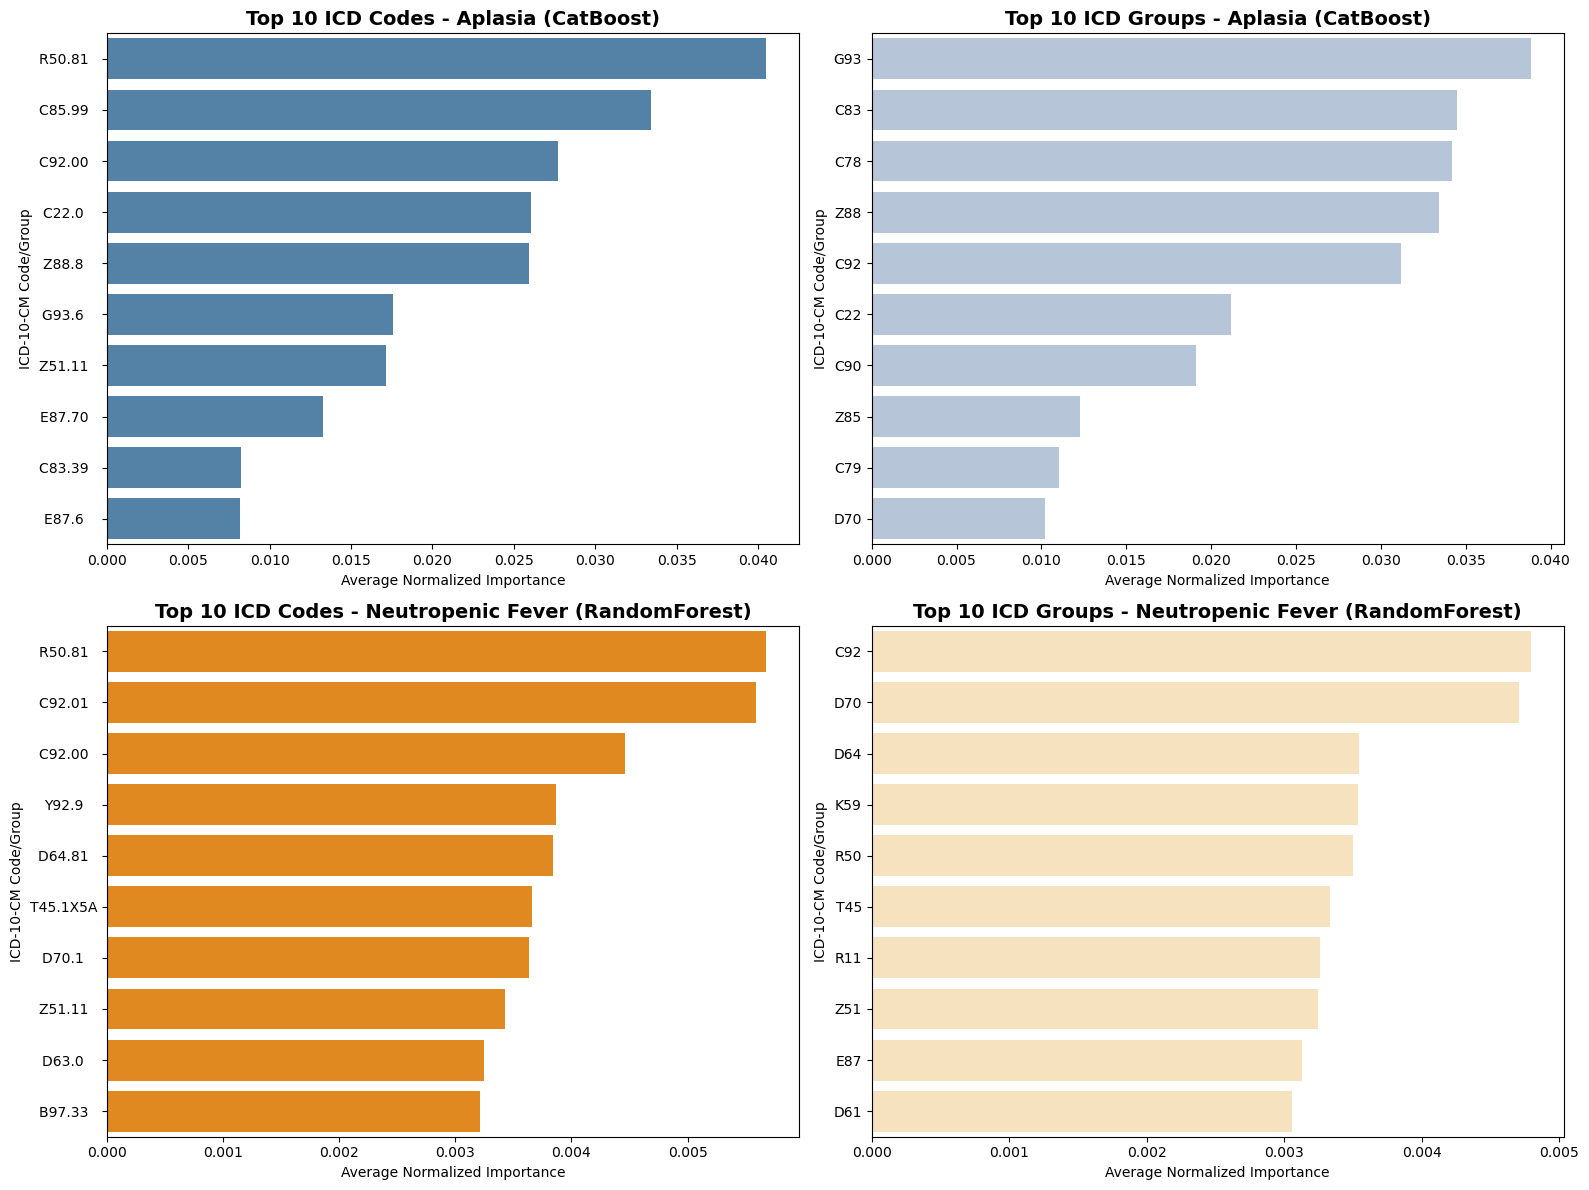

In [8]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def format_icd(code):
    """Adds a dot after the 3rd character if the code is long enough."""
    if len(str(code)) > 3:
        return f"{code[:3]}.{code[3:]}"
    return str(code)

def plot_subplot(df, ax, title, color):
    # Apply the dot formatting to the 'Feature' column for display
    plot_df = df.head(10).copy()
    plot_df['Feature'] = plot_df['Feature'].apply(format_icd)
    
    sns.barplot(data=plot_df, x='Importance', y='Feature', color=color, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Normalized Importance')
    ax.set_ylabel('ICD-10-CM Code/Group')

# Top Row: Aplasia (CatBoost)
plot_subplot(aplasia_full, axes[0, 0], 'Top 10 ICD Codes - Aplasia (CatBoost)', 'steelblue')
plot_subplot(aplasia_groups, axes[0, 1], 'Top 10 ICD Groups - Aplasia (CatBoost)', 'lightsteelblue')

# Bottom Row: Neutropenic Fever (RandomForest)
plot_subplot(nf_full, axes[1, 0], 'Top 10 ICD Codes - Neutropenic Fever (RandomForest)', 'darkorange')
plot_subplot(nf_groups, axes[1, 1], 'Top 10 ICD Groups - Neutropenic Fever (RandomForest)', 'moccasin')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_combined.png', dpi=300)
plt.show()